In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv('data_science_job.csv')

 # Percetnage of missing data

In [8]:
df.isnull().mean()*100

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [37]:
df.head(7)

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0
5,21651,city_176,0.764,NaN,Has relevent experience,Part time course,Graduate,STEM,11.0,NaN,NaN,24.0,1.0
6,28806,city_160,0.920,Male,Has relevent experience,no_enrollment,High School,NaN,5.0,50-99,Funded Startup,24.0,0.0


In [9]:
df.shape

(19158, 13)

In [10]:
cols=[var for var in df.columns if df[var].isnull().mean() < 0.05 and df[var].isnull().mean()>0]

In [12]:
cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

# how much data left after Drop

In [15]:
len(df[cols].dropna())/len(df)*100

89.68577095730244

In [16]:
new_df=df[cols].dropna()

# after removable we check for distribution of data before and after removable

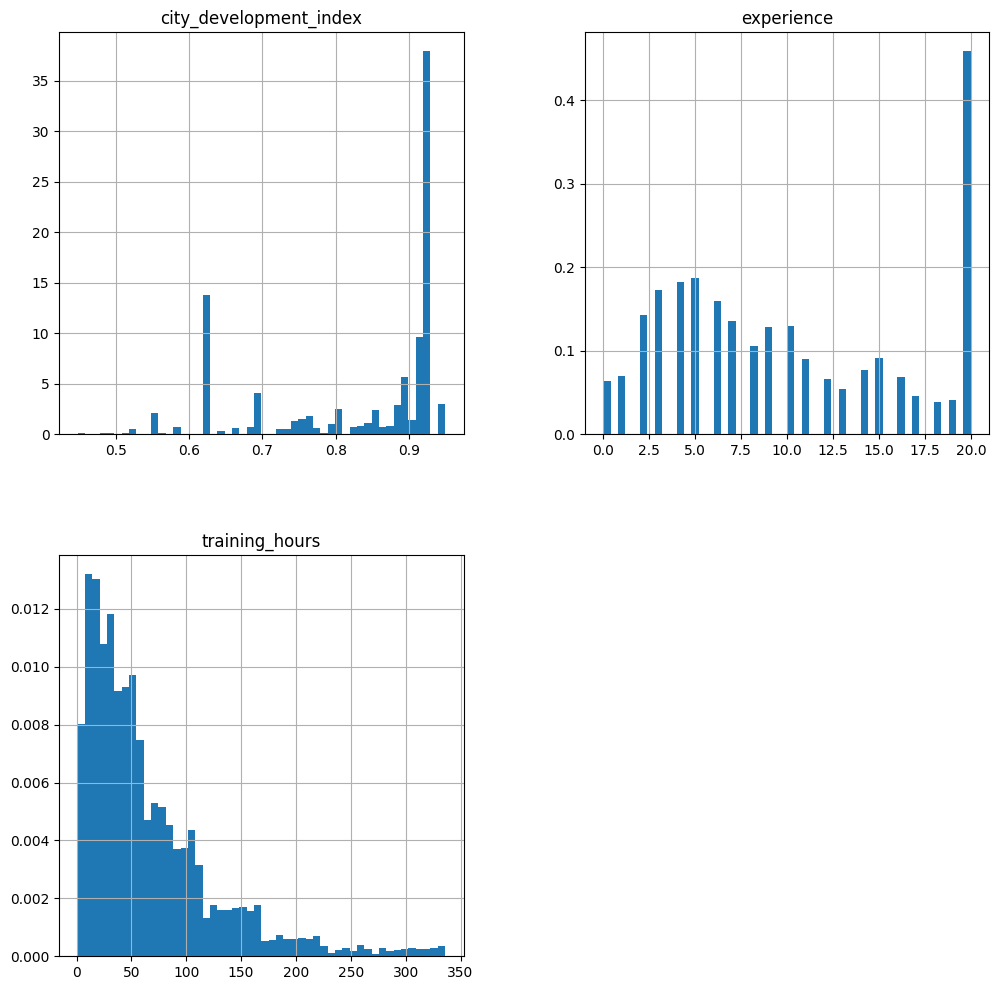

In [18]:
new_df.hist(bins=50 , density=True,figsize=(12,12))
plt.show()

<Axes: >

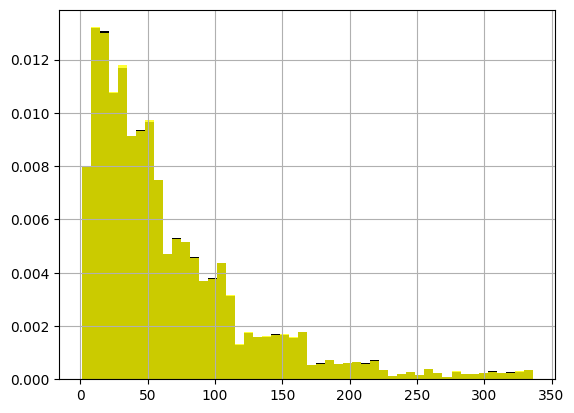

In [24]:
fig = plt.figure()
ax = fig.add_subplot(111)

df['training_hours'].hist(bins=50, ax=ax, density=True, color='black')
new_df['training_hours'].hist(
    bins=50,
    ax=ax,
    color='yellow',
    density=True,
    alpha=0.8
)

<Axes: >

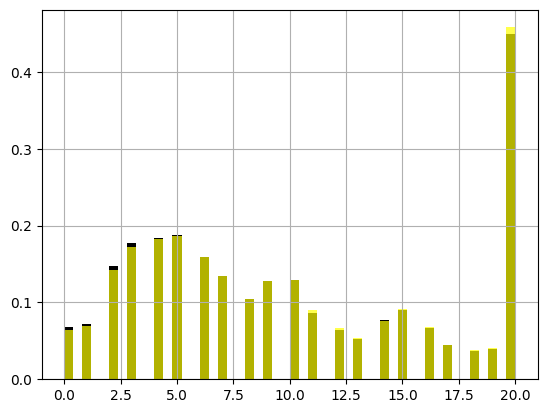

In [27]:
fig = plt.figure()
ax = fig.add_subplot(111)

df['experience'].hist(bins=50, ax=ax, density=True, color='black')
new_df['experience'].hist(
    bins=50,
    ax=ax,
    color='yellow',
    density=True,
    alpha=0.7
)

<Axes: >

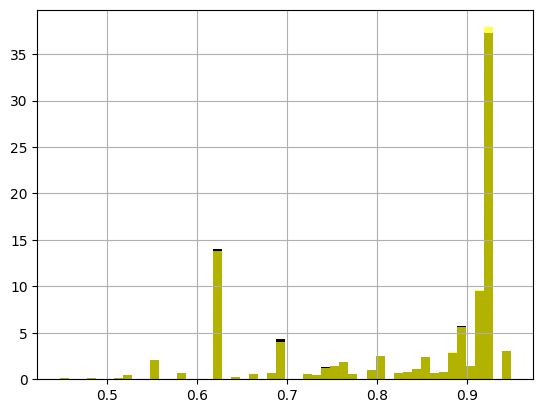

In [33]:
fig = plt.figure()
ax = fig.add_subplot(111)

df['city_development_index'].hist(bins=50, ax=ax, density=True, color='black')
new_df['city_development_index'].hist(
    bins=50,
    ax=ax,
    color='yellow',
    density=True,
    alpha=0.7
)

# For Categorical columns

In [35]:
temp = pd.concat([
    df['enrolled_university'].value_counts() / len(df),
    new_df['enrolled_university'].value_counts() / len(new_df)
], axis=1)

temp.columns = ['original', 'cca']

In [36]:
temp

,original,cca
enrolled_university,,
no_enrollment,0.721213,0.735188
Full time course,0.196106,0.200733
Part time course,0.062533,0.064079
